In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import sqlite3
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score as roc
from sklearn.model_selection import train_test_split as tts
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

In [2]:
df_raw = pd.read_csv('./dataset/creditcard.csv')

# Kết nối và lưu dữ liệu vào cơ sở dữ liệu SQLite local
conn = sqlite3.connect('credit_card.db')
df_raw.to_sql('transactions', conn, if_exists='replace', index=False)

# Đọc thử 5 dòng đầu tiên bằng câu lệnh SQL
dataset = pd.read_sql_query("SELECT * FROM transactions LIMIT 5", conn)
dataset.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


<Axes: xlabel='Class', ylabel='count'>

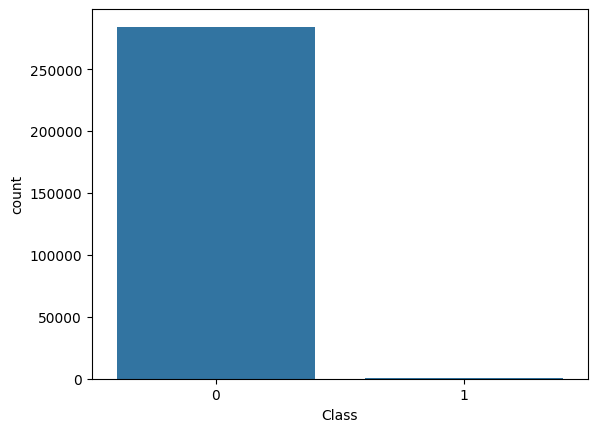

In [3]:
# Lấy dữ liệu Class bằng SQL để vẽ biểu đồ phân phối
all_data = pd.read_sql_query("SELECT Class FROM transactions", conn)
sns.countplot(x='Class', data=all_data)

In [4]:
# Sử dụng mệnh đề WHERE của SQL thay cho logic lọc cũ của Pandas
positiveDataset = pd.read_sql_query("SELECT * FROM transactions WHERE Class = 1", conn)
negativeDataset = pd.read_sql_query("SELECT * FROM transactions WHERE Class = 0", conn)

# Đóng kết nối cơ sở dữ liệu sau khi truy vấn xong dữ liệu thô
conn.close()

In [5]:
#Chia tập Train và Test
positiveTrain, positiveTest = tts(positiveDataset, test_size=0.2, random_state=21)
negativeTrain, negativeTest = tts(negativeDataset, test_size=0.5)

trainDataset = pd.concat([positiveTrain, negativeTrain])
testDataset = pd.concat([positiveTest, negativeTest])

In [6]:
#Tiền xử lý dữ liệu và cấu hình Random Forest Classifier
classifier = RandomForestClassifier(n_estimators=500, max_depth=3)

yTrain = trainDataset['Class']
yTest = testDataset['Class']

xTrain = trainDataset.drop(columns=['Class'])
xTest = testDataset.drop(columns=['Class'])

scaler = StandardScaler()
xTrain = scaler.fit_transform(xTrain)
xTest = scaler.fit_transform(xTest)

In [7]:
# Huấn luyện mô hình Random Forest Classifier
classifier.fit(xTrain, yTrain)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [8]:
# Đánh giá hiệu suất mô hình trên tập Train
predTrain = classifier.predict(xTrain)
print(classification_report(yTrain, predTrain))
print('ROC AUC Score: ', roc(yTrain, predTrain))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    142157
           1       0.92      0.68      0.78       393

    accuracy                           1.00    142550
   macro avg       0.96      0.84      0.89    142550
weighted avg       1.00      1.00      1.00    142550

ROC AUC Score:  0.8383379781459058


In [9]:
# Đánh giá hiệu suất mô hình trên tập Test
predTest = classifier.predict(xTest)
print(classification_report(yTest, predTest))
print('ROC AUC Score: ', roc(yTest, predTest))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    142158
           1       0.71      0.74      0.72        99

    accuracy                           1.00    142257
   macro avg       0.85      0.87      0.86    142257
weighted avg       1.00      1.00      1.00    142257

ROC AUC Score:  0.8685813522896205
